In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/data_raw_air_quality1.csv")
df.shape

(120, 6)

In [3]:
df.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
0,2026-02-14 00:00:00,99.9,90.8,2692.0,57.2,30.0
1,2026-02-14 01:00:00,94.1,84.5,2670.0,44.3,40.0
2,2026-02-14 02:00:00,88.9,80.1,2510.0,34.4,47.0
3,2026-02-14 03:00:00,88.2,80.1,2109.0,30.0,48.0
4,2026-02-14 04:00:00,90.3,83.4,1571.0,28.6,47.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              120 non-null    str    
 1   pm10              114 non-null    float64
 2   pm2_5             114 non-null    float64
 3   carbon_monoxide   114 non-null    float64
 4   nitrogen_dioxide  114 non-null    float64
 5   ozone             114 non-null    float64
dtypes: float64(5), str(1)
memory usage: 5.8 KB


In [5]:
df["time"].head(5)

0    2026-02-14 00:00:00
1    2026-02-14 01:00:00
2    2026-02-14 02:00:00
3    2026-02-14 03:00:00
4    2026-02-14 04:00:00
Name: time, dtype: str

In [6]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

In [7]:
df["target_worsening"] = (df["pm2_5"].shift(-1) > df["pm2_5"]).astype(int)

In [8]:
df["target_worsening"].value_counts(normalize= True)

target_worsening
0    0.5
1    0.5
Name: proportion, dtype: float64

### Test Run

In [9]:
test_df = df.copy()

test_df = test_df.dropna()

In [10]:
feature= ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "ozone"]

X = df[feature]
y = df["target_worsening"]

In [11]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [12]:
from sklearn.ensemble import RandomForestClassifier

test_rf_model = RandomForestClassifier(
    n_estimators= 100,
    max_depth= 6,
    min_samples_leaf= 5,
    min_samples_split=15,
    n_jobs= -1,
    random_state= 42
)

test_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

test_rf_proba= test_rf_model.predict_proba(X_test)[:,1]
test_rf_preds= (test_rf_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, test_rf_proba))
print(classification_report(y_test, test_rf_preds))

ROC-AUC: 0.6370370370370371
              precision    recall  f1-score   support

           0       0.80      0.53      0.64        15
           1       0.50      0.78      0.61         9

    accuracy                           0.62        24
   macro avg       0.65      0.66      0.62        24
weighted avg       0.69      0.62      0.63        24



In [14]:
pollutants= [
    "pm10", "pm2_5", "nitrogen_dioxide", "carbon_monoxide", "ozone"
]

for cols in pollutants:
    df[f"{cols}_lag1"] = df[cols].shift(1)
    df[f"{cols}_lag2"] = df[cols].shift(2)

for cols in pollutants:
    df[f"{cols}_change_1h"] = df[cols] - df[f"{cols}_lag1"]
    df[f"{cols}_change_2h"] = df[cols] - df[f"{cols}_lag2"]

for cols in pollutants:
    df[f"{cols}_roll3"] = df[cols].rolling(window= 3, min_periods= 3).mean()

In [15]:
df.isna().sum()

time                          0
pm10                          6
pm2_5                         6
carbon_monoxide               6
nitrogen_dioxide              6
ozone                         6
target_worsening              0
pm10_lag1                     6
pm10_lag2                     6
pm2_5_lag1                    6
pm2_5_lag2                    6
nitrogen_dioxide_lag1         6
nitrogen_dioxide_lag2         6
carbon_monoxide_lag1          6
carbon_monoxide_lag2          6
ozone_lag1                    6
ozone_lag2                    6
pm10_change_1h                7
pm10_change_2h                8
pm2_5_change_1h               7
pm2_5_change_2h               8
nitrogen_dioxide_change_1h    7
nitrogen_dioxide_change_2h    8
carbon_monoxide_change_1h     7
carbon_monoxide_change_2h     8
ozone_change_1h               7
ozone_change_2h               8
pm10_roll3                    8
pm2_5_roll3                   8
nitrogen_dioxide_roll3        8
carbon_monoxide_roll3         8
ozone_ro

In [16]:
df = df.dropna()

In [17]:
df.columns

Index(['time', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone',
       'target_worsening', 'pm10_lag1', 'pm10_lag2', 'pm2_5_lag1',
       'pm2_5_lag2', 'nitrogen_dioxide_lag1', 'nitrogen_dioxide_lag2',
       'carbon_monoxide_lag1', 'carbon_monoxide_lag2', 'ozone_lag1',
       'ozone_lag2', 'pm10_change_1h', 'pm10_change_2h', 'pm2_5_change_1h',
       'pm2_5_change_2h', 'nitrogen_dioxide_change_1h',
       'nitrogen_dioxide_change_2h', 'carbon_monoxide_change_1h',
       'carbon_monoxide_change_2h', 'ozone_change_1h', 'ozone_change_2h',
       'pm10_roll3', 'pm2_5_roll3', 'nitrogen_dioxide_roll3',
       'carbon_monoxide_roll3', 'ozone_roll3'],
      dtype='str')

### Base Model (LogReg)

In [18]:
X = df.drop(columns=["time", "target_worsening"])
y = df["target_worsening"]

In [19]:
print(X.shape)
print(y.shape)
print("-"* 12)
print(df.shape)

(112, 30)
(112,)
------------
(112, 32)


In [20]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(
        steps=[
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                l1_ratio= 1.0, solver= "saga", max_iter= 5000,
                C= 0.5, random_state= 42
            ))
        ]
    )

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [22]:
probs = pipe.predict_proba(X_test)[:,1]
preds = (probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

ROC-AUC: 0.856060606060606
              precision    recall  f1-score   support

           0       0.88      0.64      0.74        11
           1       0.73      0.92      0.81        12

    accuracy                           0.78        23
   macro avg       0.80      0.78      0.78        23
weighted avg       0.80      0.78      0.78        23



### RandomForest

In [23]:
X = df.drop(columns=["time", "target_worsening"])
y = df["target_worsening"]

In [24]:
print(X.shape)
print(y.shape)
print("-"* 12)
print(df.shape)

(112, 30)
(112,)
------------
(112, 32)


In [25]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [26]:
rf_model = RandomForestClassifier(
    n_estimators= 100,
    max_depth= 6,
    min_samples_leaf= 5,
    min_samples_split=15,
    n_jobs= -1,
    random_state= 42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
rf_proba= rf_model.predict_proba(X_test)[:,1]
rf_preds= (rf_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_preds))

ROC-AUC: 0.7954545454545454
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        11
           1       0.79      0.92      0.85        12

    accuracy                           0.83        23
   macro avg       0.84      0.82      0.82        23
weighted avg       0.84      0.83      0.82        23



### XGBoost

In [28]:
X = df.drop(columns=["time", "target_worsening"])
y = df["target_worsening"]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators= 100,
    max_depth= 3,
    learning_rate= 0.1,
    subsample= 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    gamma= 0,
    n_jobs=-1,
    random_state= 42,
    eval_metric= "logloss",
    early_stopping_rounds= 10
)

In [30]:
xgb_model.fit(
    X_train, y_train,
    eval_set= [(X_test, y_test)],
    verbose= False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [31]:
xgb_proba= xgb_model.predict_proba(X_test)[:,1]
xgb_preds= (xgb_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print(classification_report(y_test, xgb_preds))

ROC-AUC: 0.8484848484848485
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        11
           1       0.77      0.83      0.80        12

    accuracy                           0.78        23
   macro avg       0.78      0.78      0.78        23
weighted avg       0.78      0.78      0.78        23



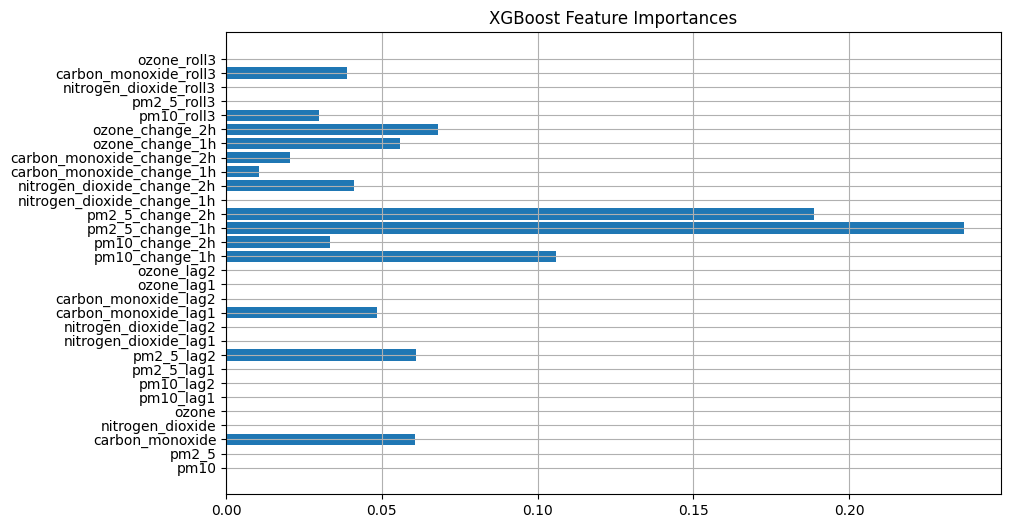

In [32]:
import matplotlib.pyplot as plt
importances = xgb_model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("XGBoost Feature Importances")
plt.grid()
plt.show()

## Model Performance Comparison

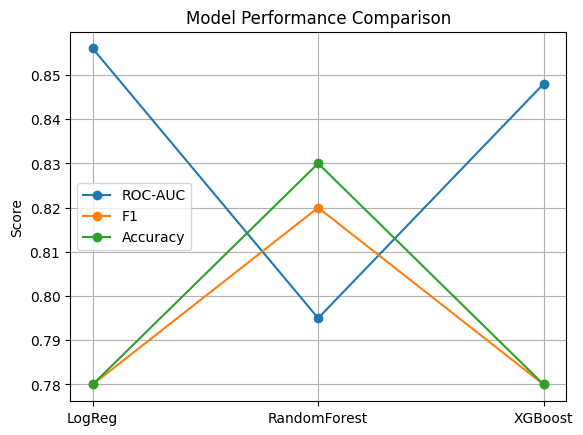

In [33]:
import matplotlib.pyplot as plt

models = ["LogReg", "RandomForest", "XGBoost"]
roc_auc = [0.856, 0.795, 0.848]
f1 = [0.78, 0.82, 0.78]
accuracy = [0.78, 0.83, 0.78]
plt.figure()

plt.plot(models, roc_auc, marker="o", label="ROC-AUC")
plt.plot(models, f1, marker="o", label="F1")
plt.plot(models, accuracy, marker="o", label="Accuracy")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

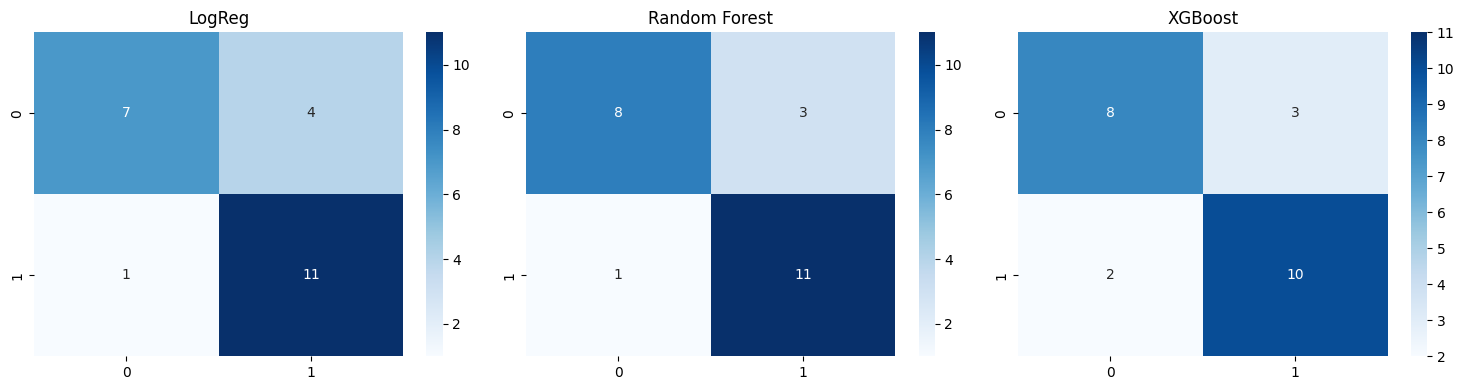

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

logreg_cm = (confusion_matrix(y_test, preds))
rf_cm = (confusion_matrix(y_test, rf_preds))
xgb_cm = (confusion_matrix(y_test, xgb_preds))

vmax = max(logreg_cm.max(), rf_cm.max(), xgb_cm.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Blues', vmax=vmax, ax=axes[0])
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', vmax=vmax, ax=axes[1])
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', vmax=vmax, ax=axes[2])

axes[0].set_title('LogReg')
axes[1].set_title('Random Forest')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()

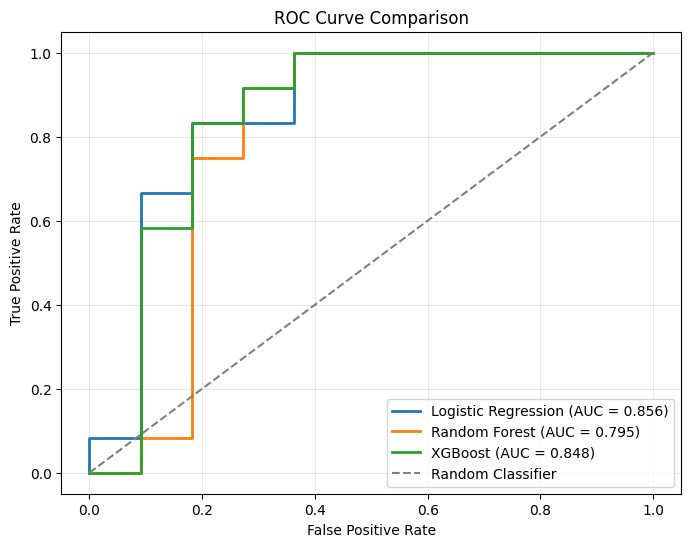

In [35]:
from sklearn.metrics import roc_curve, average_precision_score

# LogisticRegression
logreg_fpr, logreg_tpr, logreg_roc_thresholds = roc_curve(y_test, probs)
logreg_roc_auc= roc_auc_score(y_test, probs)

# RandomForest
rf_fpr, rf_tpr, rf_roc_thresholds = roc_curve(y_test, rf_proba)
rf_roc_auc= roc_auc_score(y_test, rf_proba)

# XGBoost
xgb_fpr, xgb_tpr, xgb_roc_thresholds = roc_curve(y_test, xgb_proba)
xgb_roc_auc= roc_auc_score(y_test, xgb_proba)

plt.figure(figsize=(8, 6))

plt.plot(logreg_fpr, logreg_tpr, linewidth=2,
         label=f"Logistic Regression (AUC = {logreg_roc_auc:.3f})")

plt.plot(rf_fpr, rf_tpr, linewidth=2,
         label=f"Random Forest (AUC = {rf_roc_auc:.3f})")

plt.plot(xgb_fpr, xgb_tpr, linewidth=2,
         label=f"XGBoost (AUC = {xgb_roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray",
         label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

## Conclusion

After giving all models a fair chance to shine:

- Logistic Regression stayed reliable and easy to understand
- Random Forest tried its best (respectfully)
- XGBoost competed closely and kept things interesting

Performance ended up being very similar, proving that strong features matter more than fancy models.

Logistic Regression remains the wise and interpretable baseline, Random Forest gets an honorable mention, and XGBoost is selected for deployment for its flexibility and future scalability.

No models were harmed during this experiment.

Only overfitting was avoided.